In [1]:
import os
import rasterio
import json
import numpy as np

import matplotlib.pyplot as plt

# Volume sampling based on inifinite slope analysis and displacement thresholds.

This notebooks implements a simple selection of release volumes based on an empirical corelation between displacements and the ratio of yield acceleration to peak ground acceleration of the earthqueke event. Given that the displacement is larger than a given threshold, the material is assumed to fluidize.

In [2]:
def displacement(ky, pga, M=None, pgv=None, model="scalar"):
    """ Calculation of ground displacements
    Implementation of the statistical model for ground displacements of natural slopes subject to earthquakes 
    given in [1]. Note: The statistical model is develpped for subaerial conditions.
    
    Parameters:
        ky: float or ndarray 
            Yield acceleration calculated using infinite slope analysis [g].
        pga: float or ndarray. Same dimension as ky.
            Peak ground acceleration of the event [g]. 
        M: float
            moment magnitude of the event.
        pgv: float or ndarray. Same dimension as ky.
            Peak ground velocity of the event [cm/s].
        model: string
            Different models. Options are "scalar" or "vector". If "scalar", then M must be supplied. 
            If "vector", then pgv must be supplied. Default is "scalar".
        
    Returns:
        ln(displacements) [cm], standard_deviation: float or ndarray, float or ndarray
        Logarithm of estimated displacements and associated standard deviation. 
        Standard deviation of lognormal multiplicative noise (as a function of ky/pga).  
        
    1. Rathje and Saygili, ‘Probabilistic Assessment of Earthquake-Induced Sliding Displacements of Natural Slopes’.
    """
    if model == "scalar":
        a = [-29.06, 42.49, - 19.64,-4.85, 4.89] # polynomial coefficients.
        ln_d = np.polyval(a, ky/pga) + 0.72*np.log(pga) + 0.89*(M-6)
        sigma_ln = np.polyval([-0.539, 0.789, 0.732], ky/pga)
    elif model == "vector":
        a = [-30.5, 44.75, -20.84, -4.58, -1.56]
        ln_d = np.polyval(a, ky/pga) - 0.64*np.log(pga) + 1.55*np.ln(pgv)
        sigma_ln = 0.405 + 0.524*(ky/pga)
    return(ln_d, sigma_ln)

## Plot displacements.

In [3]:
ky = np.linspace(0, 0.4, 100)
pga = np.linspace(0.01, 1., 100)
M = 6.
kys, pgas = np.meshgrid(ky, pga)

In [4]:
lnd, ln_sigma = displacement(kys, pgas, M)
d = np.exp(lnd)
log_d = lnd*np.log10(np.exp(1))
sigma = np.exp(ln_sigma)

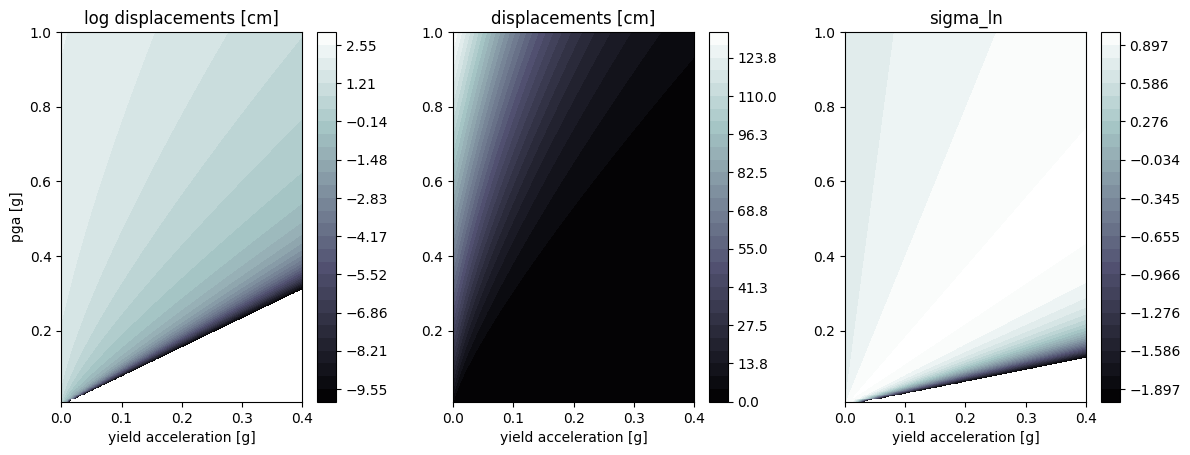

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, sharey=False)
fig.set_figwidth(14)

#d_levels = np.linspace(start=np.min(d), stop=np.max(d),num=30)
d_lnlevels = np.linspace(start=-10, stop=3,num=30)
contour1 = ax1.contourf(kys, pgas, log_d, levels=d_lnlevels, cmap=plt.cm.bone)
ax1.set_xlabel("yield acceleration [g]")
ax1.set_ylabel("pga [g]")

cbar1 = fig.colorbar(contour1, ax=ax1)
ax1.set_title('log displacements [cm]')

d_levels = np.linspace(start=np.min(d), stop=np.max(d),num=30)
contour2 = ax2.contourf(kys, pgas, d, levels=d_levels, cmap=plt.cm.bone)
ax2.set_xlabel("yield acceleration [g]")

cbar2 = fig.colorbar(contour2, ax=ax2,)
ax2.set_title('displacements [cm]')

sigma_levels = np.linspace(start=-2, stop=1.,num=30)
contour3 = ax3.contourf(kys, pgas, ln_sigma, levels=sigma_levels, cmap=plt.cm.bone)
ax3.set_xlabel("yield acceleration [g]")

cbar3 = fig.colorbar(contour3, ax=ax3)
ax3.set_title('sigma_ln')

plt.subplots_adjust(wspace=0.3)

In [81]:
from scipy.optimize import bisect

# We want to calculate thresholds of the yield acceleration so that probability that displacements are larger than delta
# may be calculated according to the cummulative probability associated with the yield acceleration.
logpga = np.log10(0.6)
logky = np.log(np.linspace(0.1, 1., 10))
M = 7.
delta = 2.

In [82]:
def f(logky):
    logd, logsigma = displacement(logky=logky, logpga=logpga, M=M)
    return(logd - np.log10(delta))

In [98]:
for delta in [1., 3., 5., 10.]:
    root_logky = bisect(f, -3, 3)
    print(root_logky, f(root_logky))

3.0 0.0
-0.46917032971441586 5.574041228584292e-12
-0.5274219435100349 2.73003841755326e-12
-0.6194113813976401 -2.227551476607914e-12


In [96]:
10.**displacement(root_logky, logpga, M=M)[0]

np.float64(3.0000000000385043)

1.9952623149688795

## Computing exceedance probabilities of displacement

In [73]:

def displacement(logky, logpga, M=None, logpgv=None, model="scalar"):
    """ Calculation of ground displacements
    Implementation of the statistical model for ground displacements of natural slopes subject to earthquakes 
    given in [1]. Note: The statistical model is develpped for subaerial conditions.
    
    Parameters:
        logky: float or ndarray 
            Log (Base 10) of Yield acceleration calculated using infinite slope analysis [g].
        logpga: float or ndarray. Same dimension as ky.
            Log (Base 10) of Peak ground acceleration of the event [g]. 
        M: float
            moment magnitude of the event.
        logpgv: float or ndarray. Same dimension as ky.
            Log (Base 10) of Peak ground velocity of the event [cm/s].
        model: string
            Different models. Options are "scalar" or "vector". If "scalar", then M must be supplied. 
            If "vector", then pgv must be supplied. Default is "scalar".
        
    Returns:
        Log of displacements [cm], Log of standard_deviation: float or ndarray, float or ndarray
        Logarithm of estimated displacements and associated standard deviation. 
        Standard deviation of lognormal multiplicative noise (as a function of ky/pga).  
        
    1. Rathje and Saygili, ‘Probabilistic Assessment of Earthquake-Induced Sliding Displacements of Natural Slopes’.
    """
    ky_pga_ratio = 10**(logky - logpga)
    logscale_factor = np.log10(np.exp(1))
    lnpga = logpga/logscale_factor
    
    if model == "scalar":
        a = [-29.06, 42.49, - 19.64,-4.85, 4.89] # polynomial coefficients.
        ln_d = np.where(ky_pga_ratio < 1., np.polyval(a, ky_pga_ratio) + 0.72*lnpga + 0.89*(M-6), 0.)
        sigma_ln = np.where(ky_pga_ratio < 1., np.polyval([-0.539, 0.789, 0.732], ky_pga_ratio), 0.)
    elif model == "vector":
        lnpgv = logpgv/np.log10(np.exp(1))
        a = [-30.5, 44.75, -20.84, -4.58, -1.56]
        ln_d = np.where(ky_pga_ratio < 1., np.polyval(a, ky_pga_ratio) - 0.64*lnpga + 1.55*lnpgv, 0)
        sigma_ln = np.where(ky_pga_ratio, 0.405 + 0.524*(ky_pga_ratio), 0.)
    return(ln_d*logscale_factor, sigma_ln*logscale_factor)

In [25]:
def read_tif(fname):
    "Read .tif data and profile using rasterio."
    #logger.info(f"Read file: {fname}")
    with rasterio.open(fname) as src:
        #data = np.ma.masked_equal(src.read(1), src.nodata)
        data = src.read(1)
        msk = np.where(src.read_masks(1) == src.nodata, False, True)
        profile = src.profile.copy()
    return data, msk, profile

In [27]:
# load cummulative

def load_cummulative(working_dir):
    # load json file
    with open(os.path.join(working_dir, "content.json"),'r') as f:
        content = json.load(f)

    # Initialize lists to store raster data and no-data values
    rasters = []
    thresholds = []
    #nodata_vals = []

    # Read all rasters and store the data
    for e in content:
        thresholds.append(e["threshold"])
        raster_path = os.path.join(working_dir, e["file"])
        raster_data, msk, profile = read_tif(raster_path)
        rasters.append(raster_data)
    return(np.stack(rasters), np.array(thresholds))

In [105]:
rundir = "/home/ebr/projects/release-volume-sampler/generated/messina_001_20241023_071936"
ky_dir = os.path.join(rundir, "yield_acceleration/cummulative")
pga_dir = os.path.join(rundir, "shakemaps")
delta = 0.5

cummulative_ky, ky_thresholds = load_cummulative(ky_dir)
cummulative_pga, pga_thresholds = load_cummulative(pga_dir)

In [ ]:
print(cummulative_ky.shape, ky_thresholds.shape)
print(cummulative_pga.shape, pga_thresholds.shape)

In [107]:
ky_centers = 0.5*(ky_thresholds[1:] + ky_thresholds[:-1])
pga_centers = 0.5*(pga_thresholds[1:] + pga_thresholds[:-1])

In [108]:
kys, pgas = np.meshgrid(ky_centers, pga_centers)
log_d, log_sigma = displacement(kys, pgas, M)

In [109]:
d_is_bigger = log_d > np.log10(delta)

In [ ]:
kys[d_is_bigger], pgas[d_is_bigger]

In [ ]:
d_is_bigger.shape

In [112]:
ky_density = np.diff(cummulative_ky, axis=0)
pga_density = np.diff(cummulative_pga, axis=0)

In [113]:
probs = np.zeros(pga_density.shape[1:])

# Naive implementation.
for i in range(pga_density.shape[1]):
    for j in range(pga_density.shape[2]):
        probs[i,j] = np.sum(np.outer(pga_density[:,i,j], ky_density[:,i,j])[d_is_bigger])

In [ ]:
plt.imshow(probs)

In [ ]:
(pga_density[:,np.newaxis]* ky_density[np.newaxis,:]).shape

In [121]:
# Vectorized!
P = np.sum((pga_density[:,np.newaxis]* ky_density[np.newaxis,:])[d_is_bigger,:], axis=0)

In [ ]:
plt.imshow(P)

## Compute cumulative probabilities of shakemaps

In [112]:
import csv

shakemaps_filename = "/home/ebr/projects/release-volume-sampler/input/shakemaps/messina_1908/predicted_data_NN_Messina_1908.json"
source_parameters_filename = "/home/ebr/projects/release-volume-sampler/input/shakemaps/messina_1908/source_parameters.csv"
shake_value = "Z_pga"
thresholds = np.linspace(-3,0,30)

# Load shakemaps from file 
with open(shakemaps_filename, 'r') as f:
    shakemaps = json.load(f)
    

# Load source parameters
source_parameters = []
with open(source_parameters_filename, newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        source_parameters.append(row)

In [113]:
def cummulative(samples, xs, weights=None, axis=-1):
    if weights is None:
        n = samples.shape[axis]
        weights = np.ones(n)/n
    # Using np.average
    #return(np.vstack([np.average(samples < x, weights=weights, axis=axis) for x in xs]))
    return(np.vstack([np.average(samples < x, weights=weights, axis=axis) for x in xs]))

In [114]:
shakemaps_cummulative =  []
for _,point in shakemaps.items():
    shakemaps_cummulative.append(
        {
            "lon": point["lon"],
            "lat": point["lat"],
            "cummulative": cummulative(np.array(point[shake_value]), thresholds)
        }
    )

In [ ]:
shakemaps_cummulative[0]

In [118]:
shakemaps_list = [point for _,point in shakemaps.items()]

In [ ]:
shakemaps_list

In [108]:
samples = np.array(shakemaps["1000"][shake_value])


In [ ]:
plt.hist(samples, bins=20, density=True)

In [121]:
point = shakemaps["1"]

In [147]:
Z, H = [10**np.array(point[shake_param]) for shake_param in ["Z_pga", "H_pga"]]

In [ ]:
def shake_value(point):
    Z, H = [10**np.array(point[shake_param]) for shake_param in ["Z_pga", "H_pga"]]
    return np.log10(np.sqrt(Z**2 + H**2))

In [ ]:
np.log10(np.sqrt(A**2 + B**2))

In [ ]:
np.sqrt(A**2 + B**2)

In [ ]:
point.keys()

## Computing displacement quantiles.

Suppose we are give a set of yield acceleration quantiles.

In [6]:
def write_tif(fname, data, profile):
    "Write .tif data and profile using rasterio."
    print(f"Write file: {fname}")
    with rasterio.open(fname, 'w', **profile) as dst:
        dst.write(data, 1)

In [ ]:
rundir = "/home/ebr/projects/release-volume-sampler/generated/messina_001_20241022_084825"
output_dir = os.path.join(rundir, "release_volumes")
pga=0.7
magnitude = 6.

if not os.path.exists(output_dir):
    os.mkdir(output_dir)

# Load yield acceleration maps.
slope_analysis_output_folder = os.path.join(rundir, "yield_acceleration")

# load content file
with open(os.path.join(slope_analysis_output_folder, "content.json"),'r') as f:
    slope_analysis_output = json.load(f)

# Read yield acceleration output from slope analysis.
yield_acceleration_quantiles = [e for e in slope_analysis_output if e["value"] == "yield_acceleration"]

output = []
for i, element in enumerate(yield_acceleration_quantiles):
    with rasterio.open(os.path.join(slope_analysis_output_folder, element["file"])) as src:
        ky = src.read(1)
        ky_profile = src.profile.copy()
        print(ky_profile)
        
        # Calculate displacement quantiles 
        # Here we apply the fact that displacements are decreasing with ky.
        ln_d, ln_sigma = displacement(ky=ky, pga=pga, M=magnitude)
        filename = f"d_{i}.tif"
        output.append({"file": filename, 
                       "quantile": 1. - element["quantile"], "value": "displacement", "scaling": "ln"})
        write_tif(os.path.join(output_dir, filename), ln_d, ky_profile)

content_file = os.path.join(output_dir, 'content.json')
print("Write file: {}".format(content_file))
with open(content_file, 'w') as f:
    json.dump(output, f, indent=4)

In [ ]:
src.profile

Next:
1. Create sampling proceedure for volumes by inverse transfrom sampling. Most likely, the tail is more relevant. Can I sample more of those?
2. How do I decide the depth of the volume? Can I sample that also?

# Loading PGA and PGV values.

PGA and PGV values are loaded and interpolated over the grid.

In [ ]:
from pyproj import CRS, Transformer
from scipy.interpolate import RegularGridInterpolator

shakemaps_filename = "/home/ebr/projects/release-volume-sampler/shakemaps/messina_1908/predicted_data_NN_Messina_1908.json"
rundir = "/home/ebr/projects/release-volume-sampler/generated/messina_001_20241008_115914"
slope_analysis_output_folder = os.path.join(rundir, "slope_analysis")
shakemaps_dir = os.path.join(rundir, "shakemaps")
ky_file = "ky_0.tif"
shake_value = 'Z_pga'
shake_sample = 0
interpolation_method = 'linear' # “linear”, “nearest”, “slinear”, “cubic”, “quintic” and “pchip”

# Extract grid values and create grid interpolation.
with open(shakemaps_filename, 'r') as f:
    shakemaps = json.load(f)

def interpolate_shakemap(shakemaps, shake_value, shake_sample, interpolation_method, bbox, nx, ny):
    lon_shake, lat_shake, data = zip(*[(point['lon'], point['lat'], point[shake_value][shake_sample]) for _, point in shakemaps.items()])
    lon, lat = sorted(list(set(lon_shake))), sorted(list(set(lat_shake))) # Extract unique values in ascending order.
    data = np.reshape(data, (len(lon), len(lat)), order='C') # Reshape data.

    shake_interp = RegularGridInterpolator(points=(np.array(lon), np.array(lat)), values=data, method=interpolation_method)
    # verify that interpolation is exact at grid values.
    rss = np.array([(shake_interp((point['lon'], point['lat'])) - point[shake_value][shake_sample])**2 for _,point in shakemaps.items()]).sum()
    print("RSS at grid points: {}".format(rss))
    # Compute pga values.
    #shake_values = shake_interp(np.meshgrid(lon_r, lat_r, indexing='ij'))
    lat = np.linspace(bbox.left, bbox.right, num=nx)
    lon = np.linspace(bbox.bottom, bbox.top, num=ny)
    latlat, lonlon = np.meshgrid(lat, lon, indexing='ij')
    shake_values = shake_interp((latlat, lonlon))
    return(shake_values)

In [ ]:
# Interpolate values over computational region
with rasterio.open(os.path.join(slope_analysis_output_folder, ky_file)) as src:
    ky = src.read(1)
    ky_profile = src.profile.copy()

    # From local projection northing, easting to WGS 84: lat [North], lon[East]
    #transformer = Transformer.from_crs(crs_from=ky_profile['crs'], crs_to=CRS.from_epsg(4326), always_xy=True)
    #lon_r, lat_r = zip(*[transformer.transform(*src.xy(row, col)) for (row, col) in zip(range(src.width),range(src.height))])
    for shake_sample in range(3):
        shake_values = interpolate_shakemap(shakemaps=shakemaps,
                            shake_value=shake_value,
                            shake_sample=shake_sample,
                            interpolation_method=interpolation_method,
                            bbox=src.bounds,
                            nx=ky_profile["width"],
                            ny=ky_profile["height"]) 
        write_tif(os.path.join(shakemaps_dir, "pga_{}.tif".format(shake_sample)), shake_values, ky_profile)


In [ ]:
bbox

In [ ]:
ky_profile

In [27]:
lat = np.linspace(bbox.left, bbox.right, num=ky_profile["width"])
lon = np.linspace(bbox.bottom, bbox.top, num=ky_profile["height"])
latlat, lonlon = np.meshgrid(lat, lon, indexing='ij')

In [ ]:
lat, latlat

In [ ]:
for shake_sample in range(3):
    shake_values = interpolate_shakemap(shakemaps=shakemaps,
                        shake_value=shake_value,
                        shake_sample=shake_sample,
                        interpolation_method=interpolation_method,
                        bbox=bbox,
                        nx=ky_profile["width"],
                        ny=ky_profile["height"]) 
    write_tif(os.path.join(output_dir, "pga_{}.tif".format(shake_sample)), shake_values, ky_profile)

In [212]:
def read_tif(fname):
    "Read .tif data and profile using rasterio."
    #logger.info(f"Read file: {fname}")
    with rasterio.open(fname) as src:
        data = src.read(1)
        msk = np.where(src.read_masks(1) == src.nodata, False, True)
        profile = src.profile.copy()
    return data, msk, profile

slope_data, slope_msk, slope_profile = read_tif("/home/ebr/projects/release-volume-sampler/generated/messina_001_20241022_194154/slope.tif")

In [ ]:
plt.imshow(slope_msk)

In [ ]:
slope_msk

In [ ]:
slope_data[slope_msk]

In [ ]:
slope_data.data[~mask]

In [204]:
mask = ~np.isnan(slope_data).mask

In [ ]:
mask

In [ ]:
slope_data.data[mask]

In [192]:
init = np.zeros(slope_data.shape)
init[mask] = slope_flat

In [ ]:
np.sum(slope_flat.data)

In [ ]:
# Old code...
def calculate_displacements(rundir, shakemaps_filename, write_shakemaps=False, write_displacements=False, make_plots=False):
    #pga=0.7
    magnitude = 7.
    shake_value = 'Z_pga'
    nr_of_shake_samples = 10
    interpolation_method = 'linear' # “linear”, “nearest”, “slinear”, “cubic”, “quintic” and “pchip”

    # Load shakemaps from file 
    with open(shakemaps_filename, 'r') as f:
        shakemaps = json.load(f)
    
    # Create output directories
    if write_displacements:
        displacements_dir = os.path.join(rundir, "displacements")
        create_dir(displacements_dir)
    if write_shakemaps:
        shakemaps_dir = os.path.join(rundir, "shakemaps")
        create_dir(shakemaps_dir)
    if make_plots:
        figure_dir = os.path.join(rundir, "figures")
        create_dir(figure_dir)
    
    # Load yield acceleration maps.
    ky_folder = os.path.join(rundir, "yield_acceleration")

    # load content file
    with open(os.path.join(ky_folder, "content.json"),'r') as f:
        slope_analysis_output = json.load(f)

    # Read yield acceleration output from slope analysis.
    yield_acceleration_quantiles = [e for e in slope_analysis_output if e["value"] == "yield_acceleration"]

    displacement_content, shakemap_content = [], []
    for shake_sample in range(nr_of_shake_samples):
        for i, element in enumerate(yield_acceleration_quantiles):
            with rasterio.open(os.path.join(ky_folder, element["file"])) as src:
                logky = src.read(1)
                ky_profile = src.profile.copy()
                if i == 0:
                    # New shakemap.
                    logpga = interpolate_shakemap(shakemaps=shakemaps,
                                        shake_value=shake_value,
                                        shake_sample=shake_sample,
                                        interpolation_method=interpolation_method,
                                        bbox=src.bounds,
                                        n_cols=ky_profile["width"],
                                        n_rows=ky_profile["height"])
                    if write_shakemaps:
                        filename = "pga_{}.tif".format(shake_sample)
                        shakemap_content.append({
                            "file": filename,
                            "sample":shake_sample,
                            "value":shake_value,
                            "scale":"log10",
                            "unit":"g"
                        })
                        write_tif(os.path.join(shakemaps_dir, filename), logpga, ky_profile)
            
                # Calculate displacement quantiles 
                # Here we apply the fact that displacements are decreasing with ky.
                logd, logsigma = displacement(logky=logky, logpga=logpga, M=magnitude)
                if make_plots:
                    plot_raster(logd, "displacement_{}_{}.png".format(shake_sample, i))
                
                
                if write_displacements:
                    filename = f"d_{i}_{shake_sample}.tif"
                    displacement_content.append({
                        "file": filename, 
                        "quantile": 1. - element["quantile"],
                        "shakemaps_filename": shakemaps_filename,
                        "shakemap_sample": shake_sample,
                        "shake_value": shake_value,
                        "value": "displacement", 
                        "scale": "log10",
                        "unit":"cm"
                        })
                    write_tif(os.path.join(displacements_dir, filename), logd, ky_profile)
                
    if write_displacements:
        content_file = os.path.join(displacements_dir, 'content.json')
        logger.info("Write file: {}".format(content_file))
        with open(content_file, 'w') as f:
            json.dump(displacement_content, f, indent=4)
    
    if write_shakemaps:
        content_file = os.path.join(shakemaps_dir, 'content.json')
        logger.info("Write file: {}".format(content_file))
        with open(content_file, 'w') as f:
            json.dump(shakemap_content, f, indent=4)


def plot_raster(data, filename):
    """
        Applied to debug shakemap interpolation.
    """
    fig, ax = plt.subplots()
    figure_dir = "figures"
    im = ax.imshow(data, interpolation='bilinear', origin='upper')
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.01)
    plt.savefig(os.path.join(figure_dir, filename))


def interpolate_shakemap(shakemaps, shake_value, shake_sample, interpolation_method, bbox, n_rows, n_cols, make_plots=False):
    # Create grid interpolator
    lon_shake, lat_shake, data = zip(*[(point['lon'], point['lat'], point[shake_value][shake_sample]) for _, point in shakemaps.items()])
    grid_shake = np.array(list(set(lon_shake))), np.array(list(set(lat_shake))) # Extract unique values 
    [g.sort() for g in grid_shake] # in ascending order.
    grid_shake_shape = grid_shake[0].shape[0], grid_shake[1].shape[0]
    data = np.reshape(data, grid_shake_shape, order='C') # Reshape data. 
    # Lon fixed, Lat change -> C order. Location of data(ij): lowerleft + (j*delta_lat, i*delta_lon) 
    if make_plots:
        plot_raster(np.flip(data.T,-1), os.path.join(figure_dir, "shakemap.png"))
    shake_interp = RegularGridInterpolator(points=grid_shake, values=np.flip(data.T,-1), method=interpolation_method) # Data need to be ij matrix format (See np.meshgrid)
    
    # verify that interpolation is exact at grid values.RSS nonzero with flipped axes...
    #rss = np.array([(shake_interp((point['lon'], point['lat'])) - point[shake_value][shake_sample])**2 for _,point in shakemaps.items()]).sum()
    #logger.debug("RSS at grid points: {}".format(rss))
    
    # Interpolate grid.
    grid_int = np.meshgrid(np.linspace(bbox.left, bbox.right, num=n_cols), np.linspace(bbox.bottom, bbox.top, num=n_rows), indexing='ij')
    shake_values = shake_interp(grid_int)
    if make_plots:
        plot_raster(shake_values, "shake_values.png")
    return(np.flip(shake_values,-1).T)
